<a href="https://colab.research.google.com/github/DiegoAbarza77/Deep_Learning/blob/main/Entregable_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN 3 - Parte 1
## Implementación modelo de lenguaje

---
Deep Learning sección 002D  

**Docente:** Marcelo Tapia Contreras    

**Estudiantes:**
- Diego Abarza
- Axel Altamirano
- Felipe Crisostomo
- Milton Espinoza
- Dante Moya
- Valentina Puentes


---

# Modelos del lenguaje con RNNs

En el siguiente informe vamos a entrenar un modelo del lenguaje basado en caracteres con Recurrent Neural Networks. Asimismo, utilizaremos el modelo para generar texto. En particular, alimentaremos nuestro modelo con obras de la literatura clásica en castellano para obtener una red neuronal que sea capaz de "escribir" fragmentos literarios.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consistirá en un archivo de texto con el contenido íntegro en castellano antiguo de El Ingenioso Hidalgo Don Quijote de la Mancha, disponible de manera libre en la página de [Project Gutenberg](https://www.gutenberg.org).

## 1. Carga y procesado del texto

Primero, vamos a descargar el libro e inspeccionar los datos. El fichero a descargar es una versión en .txt del libro de Don Quijote, a la cual se le han borrado introducciones, licencias y otras secciones para dejarlo con el contenido real de la novela.

In [ ]:
import numpy as np
import keras
import matplotlib.pyplot as plt
from keras.callbacks import LambdaCallback
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, Dropout
from keras.layers import SimpleRNN
import random
import io
from google.colab import drive
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
drive.mount('/content/drive')

# Para el archivo en drive
path = '/content/drive/MyDrive/Evaluacion3_DeepLearning/don_quijote.txt'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Una vez descargado, vamos a leer el contenido del fichero en una variable. Adicionalmente, convertiremos el contenido del texto a minúsculas para ponérselo un poco más fácil a nuestro modelo (de modo que todas las letras sean minúsculas y el modelo no necesite diferenciar entre minúsculas y mayúsculas).

In [ ]:
# 1.1. Leer todo el contenido del fichero en una única variable text y convertir el string a minúsculas


# Abrimos el archivo con la codificación utf-8 (necesaria para el castellano por los tildes y la ñ)
with io.open(path, encoding='utf-8') as f:
    # Leemos todo el contenido y aplicamos .lower() de inmediato
    text = f.read().lower()

# Imprimimos información básica para verificar que se leyó correctamente
print('Longitud total del texto (en caracteres):', len(text))

Longitud total del texto (en caracteres): 2071198


Podemos comprobar ahora que efectivamente nuestra variable contiene el resultado deseado, con el comienzo tan característico del Quijote.

In [ ]:
print("Longitud del texto: {}".format(len(text)))
print(text[0:300])

Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más


## 2. Procesado de los datos

Una de las grandes ventajas de trabajar con modelos que utilizan caracteres en vez de palabras es que no necesitamos tokenizar el texto (partirlo palabra a palabra). Nuestro modelo funcionará directamente con los caracteres en el texto, incluyendo espacios, saltos de línea, etc.

Antes de hacer nada, necesitamos procesar el texto en entradas y salidas compatibles con nuestro modelo. Como sabemos, un modelo del lenguaje con RNNs acepta una serie de caracteres y predice el siguiente carácter en la secuencia.

* "*El ingenioso don Qui*" -> predicción: **j**
* "*El ingenioso don Quij*" -> predicción: **o**

De modo que la entrada y la salida de nuestro modelo necesita ser algo parecido a este esquema. En este punto, podríamos usar dos formas de preparar los datos para nuestro modelo.

1. **Secuencia a secuencia**. La entrada de nuestro modelo sería una secuencia y la salida sería esa secuencia trasladada un caracter a la derecha, de modo que en cada instante de tiempo la RNN tiene que predecir el carácter siguiente. Por ejemplo:

>* *Input*:   El ingenioso don Quijot
>* *Output*: l ingenioso don Quijote

2. **Secuencia a carácter**. En este variante, pasaríamos una secuencia de caracteres por nuestra RNN y, al llegar al final de la secuencia, predeciríamos el siguiente carácter.

>* *Input*:   El ingenioso don Quijot
>* *Output*: e

En este laboratorio, por simplicidad, vamos a utilizar la segunda variante.

De este modo, a partir del texto, hemos de generar nuestro propio training data que consista en secuencias de caracteres con el siguiente carácter a predecir. Para estandarizar las cosas, utilizaremos secuencias de tamaño *SEQ_LENGTH* caracteres (un hiperparámetro que podemos elegir nosotros).



#### 2.1. Obtención de los caracteres y mapas de caracteres

Antes que nada, necesitamos saber qué caracteres aparecen en el texto, ya que tendremos que diferenciarlos mediante un índice de 0 a *num_chars* - 1 en el modelo. Obtener:


1.   Número de caracteres únicos que aparecen en el texto.
2.   Diccionario que asocia char a índice único entre 0 y *num_chars* - 1. Por ejemplo, {'a': 0, 'b': 1, ...}
3.   Diccionario reverso de índices a caracteres: {0: 'a', 1: 'b', ...}


In [ ]:
# 1. Obtener la lista de caracteres únicos ordenados (el vocabulario)
chars = sorted(list(set(text)))
num_chars = len(chars)

# 2. Diccionario que asocia cada carácter (char) a un índice único (0 a num_chars - 1)
char2idx = {char: idx for idx, char in enumerate(chars)}

# 3. Diccionario reverso que asocia cada índice a su carácter correspondiente
idx2char = {idx: char for idx, char in enumerate(chars)}

# Verificamos los resultados imprimiendo la información en pantalla
print(f"Número de caracteres únicos (tamaño del vocabulario): {num_chars}")
print("\nPrimeros 15 elementos del diccionario char2idx:")
print(dict(list(char2idx.items())[:15]))
print("\nPrimeros 15 elementos del diccionario reverso idx2char:")
print(dict(list(idx2char.items())[:15]))

Número de caracteres únicos (tamaño del vocabulario): 61

Primeros 15 elementos del diccionario char2idx:
{'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14}

Primeros 15 elementos del diccionario reverso idx2char:
{0: '\n', 1: ' ', 2: '!', 3: '"', 4: "'", 5: '(', 6: ')', 7: ',', 8: '-', 9: '.', 10: '0', 11: '1', 12: '2', 13: '3', 14: '4'}


#### 2.2. Obtención de secuencias de entrada y carácter a predecir

Ahora, vamos a obtener las secuencias de entrada en formato texto y los correspondientes caracteres a predecir. Para ello, recorreremos el texto completo leído anteriormente, obteniendo una secuencia de SEQ_LENGTH caracteres y el siguiente caracter a predecir. Una vez hecho, desplazarse un carácter a la izquierda y hacer lo mismo para obtener una nueva secuencia y predicción. Guardar las secuencias en una variable ***sequences*** y los caracteres a predecir en una variable ***next_chars***.

Por ejemplo, si el texto fuera "Don Quijote" y SEQ_LENGTH fuese 5, tendríamos

* *sequences* = ["Don Q", "on Qu", "n Qui", " Quij", "Quijo", "uijot"]
* *next_chars* = ['u', 'i', 'j', 'o', 't', 'e']

In [ ]:
# Definimos la longitud de la secuencia fija según las instrucciones anteriores
SEQ_LENGTH = 30
STEP = 1         # Nos desplazamos de 1 en 1 carácter según el ejemplo ("Don Q" -> "on Qu")

sequences = []   # Variable solicitada para guardar las secuencias de entrada
next_chars = []  # Variable solicitada para guardar los caracteres a predecir

# Recorremos el texto completo restando SEQ_LENGTH para no salirnos del índice al final
for i in range(0, len(text) - SEQ_LENGTH, STEP):
    # Extraemos la secuencia de longitud SEQ_LENGTH
    sequences.append(text[i : i + SEQ_LENGTH])
    # Extraemos el carácter inmediatamente siguiente
    next_chars.append(text[i + SEQ_LENGTH])

# Verificación de los resultados
print(f"Número total de secuencias (sequences) generadas: {len(sequences)}")
print(f"Número total de caracteres a predecir (next_chars): {len(next_chars)}")

# Mostramos un ejemplo real de los datos para la defensa
print("\n--- Demostración de los primeros 3 ejemplos ---")
for i in range(3):
    print(f"Ejemplo {i+1}:")
    print(f"  Input (sequences[{i}]): '{sequences[i]}'")
    print(f"  Output (next_chars[{i}]): '{next_chars[i]}'")

Número total de secuencias (sequences) generadas: 2071168
Número total de caracteres a predecir (next_chars): 2071168

--- Demostración de los primeros 3 ejemplos ---
Ejemplo 1:
  Input (sequences[0]): 'capítulo primero. que trata de'
  Output (next_chars[0]): ' '
Ejemplo 2:
  Input (sequences[1]): 'apítulo primero. que trata de '
  Output (next_chars[1]): 'l'
Ejemplo 3:
  Input (sequences[2]): 'pítulo primero. que trata de l'
  Output (next_chars[2]): 'a'


Indicar el tamaño del training set que acabamos de generar.

In [ ]:
print(" TAMAÑO DEL TRAINING SET GENERADO ")
print(f"Cantidad total de secuencias de entrenamiento (X): {len(sequences)}")
print(f"Cantidad total de caracteres a predecir (Y): {len(next_chars)}")

print("\nEjemplo de una muestra del dataset ")
print(f"Texto de entrada (Secuencia): '{sequences[0]}'")
print(f"Salida correspondiente (Siguiente carácter): '{next_chars[0]}'")

 TAMAÑO DEL TRAINING SET GENERADO 
Cantidad total de secuencias de entrenamiento (X): 2071168
Cantidad total de caracteres a predecir (Y): 2071168

Ejemplo de una muestra del dataset 
Texto de entrada (Secuencia): 'capítulo primero. que trata de'
Salida correspondiente (Siguiente carácter): ' '


Como el Quijote es muy largo y tenemos muchas secuencias, podríamos encontrar problemas de memoria. Por ello, vamos a elegir un número máximo de 200000

In [ ]:
MAX_SEQUENCES = 200000

perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

print(len(sequences))

200000


#### 2.3. Obtención de input X y output y para el modelo

Finalmente, a partir de los datos de entrenamiento que hemos generado vamos a crear los arrays de datos X e y que pasaremos a nuestro modelo.

Para ello, vamos a utilizar *one-hot encoding* para nuestros caracteres. Por ejemplo, si sólo tuviéramos 4 caracteres (a, b, c, d), las representaciones serían: (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0) y (0, 0, 0, 1).

De este modo, **X** tendrá shape *(num_sequences, seq_length, num_chars)* e **y** tendrá shape *(num_sequences, num_chars)*.



In [ ]:
NUM_CHARS = len(chars)  #61
NUM_SEQUENCES = len(sequences)

# Creamos los arrays X e y usando floats (o booleans para optimizar, mantendremos la base del profe)
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS))
y = np.zeros((NUM_SEQUENCES, NUM_CHARS))

## Tu código para rellenar X e y aquí.
# Usamos char2idx que es el diccionario de caracteres a índices que creamos en el paso 2.1
for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char2idx[char]] = 1
    y[i, char2idx[next_chars[i]]] = 1

# Verificación para confirmar que todo se rellenó con las dimensiones correctas
print("¡Matrices X e y creadas y rellenadas con éxito!")
print(f"Dimensiones de X (Input): {X.shape}")
print(f"Dimensiones de y (Output): {y.shape}")

¡Matrices X e y creadas y rellenadas con éxito!
Dimensiones de X (Input): (200000, 30, 61)
Dimensiones de y (Output): (200000, 61)


## 3. Definición del modelo y entrenamiento

Una vez tenemos ya todo preparado, es hora de definir el modelo. Definimos un modelo que utilice una **LSTM** con **128 unidades internas** más una capa Dense con el *softmax* que predice el siguiente caracter a producir. Con Adam como elección de optimizador

Una vez el modelo esté definido, entrénamos el modelo asegurandonos el loss es decreciente.

# Primera Red RNN

In [ ]:
# Red RNN
# 1. Definimos el modelo secuencial de Keras
model_rnn = Sequential()

# 2. Añadimos la capa SimpleRNN (RNN Clásica)
# input_shape recibe (longitud de secuencia, número de caracteres únicos)
model_rnn.add(SimpleRNN(128, input_shape=(SEQ_LENGTH, NUM_CHARS)))

# 3. Añadimos la capa Dense (salida) con tamaño igual a nuestro vocabulario (61)
# Softmax nos dará la probabilidad para cada uno de los 61 caracteres posibles
model_rnn.add(Dense(NUM_CHARS, activation='softmax'))

# 4. Compilamos el modelo con el optimizador Adam y la función de pérdida para clasificación categórica
model_rnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

# 5. Entrenamos el modelo por 20 épocas para el análisis comparativo
print("\nIniciando entrenamiento del modelo RNN Clásica...")
history_rnn = model_rnn.fit(
    X, y,
    batch_size=128,
    epochs=100,
    validation_split=0.05 # Dejamos un 5% para validar que no haya sobreajuste
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,189 (125.74 KB)

 Trainable params: 32,189 (125.74 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del modelo RNN Clásica...
Epoch 1/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.3224 - loss: 2.3047 - val_accuracy: 0.3637 - val_loss: 2.0701
Epoch 2/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3791 - loss: 2.0226 - val_accuracy: 0.3963 - val_loss: 1.9628
Epoch 3/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4070 - loss: 1.9298 - val_accuracy: 0.4225 - val_loss: 1.8880
Epoch 4/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4268 - loss: 1.8647 - val_accuracy: 0.4327 - val_loss: 1.8428
Epoch 5/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4409 - loss: 1.8151 - val_accuracy: 0.4420 - val_loss: 1.8053
Epoch 6/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4522 - loss: 1.7764 - val_accuracy: 0.4540 - val_loss: 1.7751
Epoch 7/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4623 - loss: 1.7419 - val_accuracy: 0.4615 - val_loss: 1.7413
Epoch 8/100
1485/1485 ━━━━━━━━

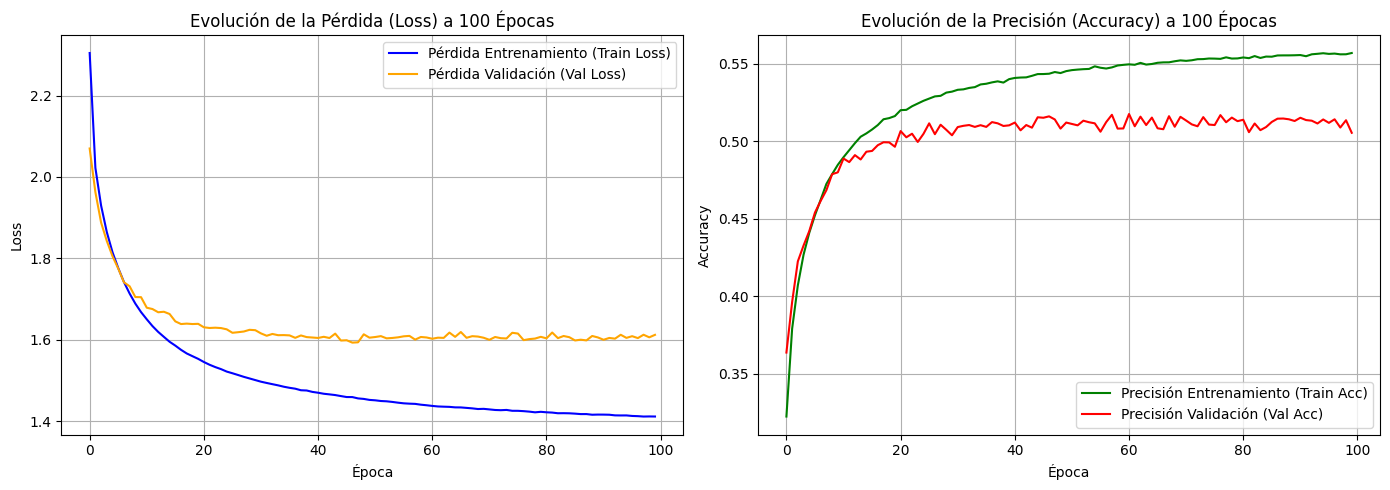

In [ ]:
plt.figure(figsize=(14, 5))

# 1. Gráfico de la Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Pérdida Entrenamiento (Train Loss)', color='blue')
if 'val_loss' in history_rnn.history:
    plt.plot(history_rnn.history['val_loss'], label='Pérdida Validación (Val Loss)', color='orange')
plt.title('Evolución de la Pérdida (Loss) a 100 Épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Gráfico de la Precisión
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['accuracy'], label='Precisión Entrenamiento (Train Acc)', color='green')
if 'val_accuracy' in history_rnn.history:
    plt.plot(history_rnn.history['val_accuracy'], label='Precisión Validación (Val Acc)', color='red')
plt.title('Evolución de la Precisión (Accuracy) a 100 Épocas')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Segunda red LSTM

In [ ]:
# 1. Definimos el modelo secuencial de Keras
model = Sequential()

# 2. Añadimos la capa LSTM
# input_shape recibe (longitud de secuencia, número de caracteres únicos)
model.add(LSTM(128, input_shape=(SEQ_LENGTH, NUM_CHARS)))

# Capa de Dropout para evitar sobreajuste en el texto
model.add(Dropout(0.2))

# 3. Añadimos la capa Dense (salida) con tamaño igual a nuestro vocabulario (61)
# Softmax nos dará la probabilidad para cada uno de los 61 caracteres posibles
model.add(Dense(NUM_CHARS, activation='softmax'))



# 4. Compilamos el modelo con el optimizador Adam y la función de pérdida para clasificación categórica
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# 'restore_best_weights=True' asegura que el modelo se quede con sus mejores parámetros (aprox. época 30).
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 5. Entrenamos el modelo con el callback activado
print("\nIniciando entrenamiento optimizado con Early Stopping y Dropout")
history = model.fit(
    X, y,
    batch_size=128,
    epochs=100,           # Dejamos 100 como límite máximo, pero se detendrá mucho antes
    validation_split=0.05, # Dejamos un 5% para validar que no haya sobreajuste
    callbacks=[early_stop] # Activamos la parada temprana aquí
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento optimizado con Early Stopping y Dropout
Epoch 1/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.2862 - loss: 2.4608 - val_accuracy: 0.3497 - val_loss: 2.1306
Epoch 2/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3546 - loss: 2.1097 - val_accuracy: 0.3900 - val_loss: 1.9882
Epoch 3/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3865 - loss: 1.9931 - val_accuracy: 0.4171 - val_loss: 1.8821
Epoch 4/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4118 - loss: 1.9103 - val_accuracy: 0.4442 - val_loss: 1.8093
Epoch 5/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.4315 - loss: 1.8458 - val_accuracy: 0.4551 - val_loss: 1.7615
Epoch 6/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4474 - loss: 1.7958 - val_accuracy: 0.4685 - val_loss: 1.7213
Epoch 7/100
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4592 - loss: 1.7540 - val_accuracy: 0.4764 - val_loss: 1.6874
Epoch 8/100

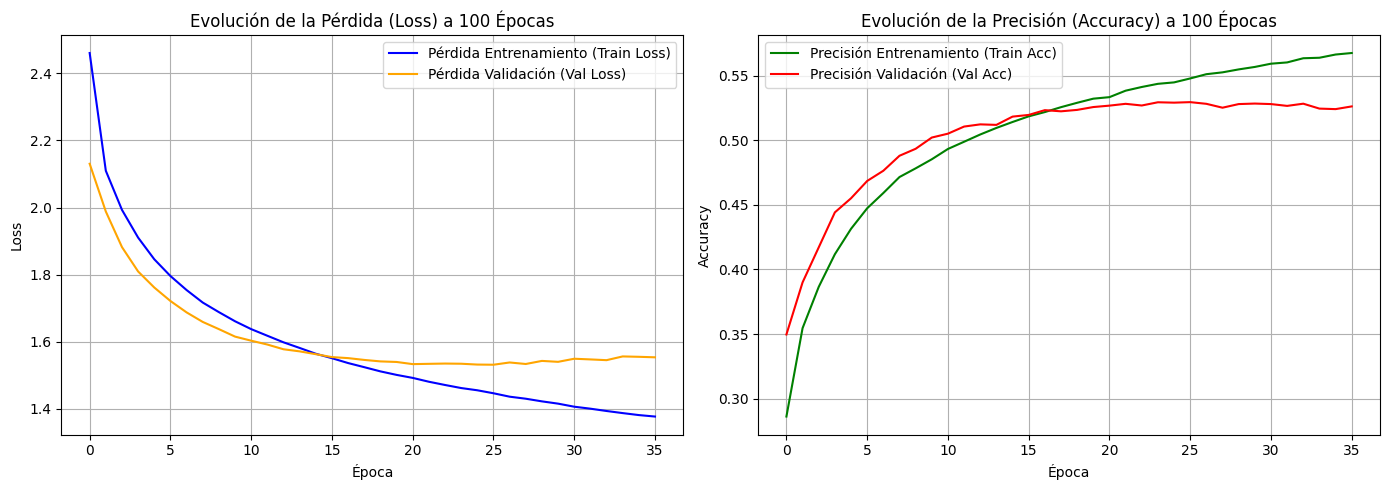

In [ ]:

plt.figure(figsize=(14, 5))

# 1. Gráfico de la Pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train Loss)', color='blue')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Pérdida Validación (Val Loss)', color='orange')
plt.title('Evolución de la Pérdida (Loss) a 100 Épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Gráfico de la Precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento (Train Acc)', color='green')
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Precisión Validación (Val Acc)', color='red')
plt.title('Evolución de la Precisión (Accuracy) a 100 Épocas')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# JUSTIFICACIÓN DE LA ARQUITECTURA (LSTM vs. SimpleRNN)

Por qué se descarta la SimpleRNN: Al analizar las curvas de la RNN clásica, se observa un estancamiento temprano (efecto plateau). La precisión de validación se congeló rápidamente cerca del 51% y la pérdida no bajó de 1.61. Esto ocurre por el problema del Desvanecimiento del Gradiente (Vanishing Gradient): la RNN clásica tiene "mala memoria" a corto plazo y olvida el inicio de la secuencia (de longitud 40). Aunque es una red más simple, tardó 14 minutos de entrenamiento para no entregar mejoras sustanciales.

Por qué se elige la LSTM: La LSTM incorpora una celda de memoria interna regulada por compuertas lógicas (olvido, entrada y salida). Como se observa en la curva de entrenamiento de la LSTM sin control, el modelo tiene una capacidad de aprendizaje drásticamente superior, logrando romper el estancamiento y alcanzando un ~56% de accuracy en el set de entrenamiento.

# Resumen de Datos Clave
SimpleRNN: Train Accuracy: ~59.73% | Val Accuracy: ~51% | Comportamiento: Convergencia rápida con estabilidad en 20 épocas.

LSTM Original: Train Accuracy: ~66% | Val Accuracy: ~48.7% (al final) | Comportamiento: Sobreajuste severo.

LSTM con Early Stopping: Train Accuracy: ~56% | Val Accuracy Salvado: ~51% | Comportamiento: Convergencia óptima controlada.

El Early Stopping evitó que la red LSTM sobreajustara los datos de entrenamiento.

# ANÁLISIS DE HIPERPARÁMETROS Y TIEMPOS DE CÓMPUTO
El rendimiento del modelo final se optimizó mediante el ajuste estratégico de los siguientes hiperparámetros y callbacks:

Tamaño del Lote (Batch Size = 128): Permite procesar 128 secuencias en paralelo antes de actualizar los pesos de la red. Esto ofreció un gradiente estable y un balance óptimo de carga para la GPU.

Tasa de Aprendizaje (Learning Rate = 0.001 con Adam): El optimizador Adam ajusta la tasa de manera adaptativa, permitiendo un descenso fluido y rápido del error durante las primeras 20 épocas.

Optimización de Épocas mediante Parada Temprana (EarlyStopping):

El peligro detectado: En el experimento de la LSTM sin control, dejar correr el modelo hasta las 100 épocas causó un Sobreajuste Severo (Overfitting). El modelo se dedicó a memorizar el libro, tardando 17 minutos en completarse para terminar arruinando la precisión de validación (la cual cayó por debajo del 50%).

La solución aplicada con Early Stopping: Se implementó la parada temprana con una paciencia de 10 épocas. El algoritmo detectó que la pérdida de validación alcanzó su mínimo histórico en la época 32 y, al notar que ya no mejoraba, detuvo automáticamente el entrenamiento en la época 42.

Impacto en el Tiempo: Activar esta restricción redujo el tiempo de entrenamiento de 17 minutos a solo 7 minutos.

In [ ]:

# 1. Tomamos el 5% final de los datos como set de validación (igual al validation_split)
val_split_index = int(len(X) * 0.95)
X_val = X[val_split_index:]
y_val = y[val_split_index:]

# 2. El modelo realiza las predicciones sobre el set de validación
print("Generando predicciones del modelo optimizado...")
y_pred_probabilities = model.predict(X_val, batch_size=128)

# 3. Convertimos las probabilidades (Softmax) y los vectores One-Hot a índices enteros
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# 4. Calculamos y mostramos el reporte detallado de métricas globales
# Usamos 'weighted' porque el vocabulario de caracteres está desbalanceado (hay más espacios y vocales que letras raras)
print("REPORTES DE MÉTRICAS GLOBALES (VALIDACIÓN)")

# Calculamos las métricas resumidas ponderadas
report_dict = classification_report(y_val_classes, y_pred_classes, output_dict=True, zero_division=0)
weighted_metrics = report_dict['weighted avg']

print(f"Accuracy Global:  {accuracy_score(y_val_classes, y_pred_classes):.4f}")
print(f"Precision (Ponderada): {weighted_metrics['precision']:.4f}")
print(f"Recall (Ponderado):    {weighted_metrics['recall']:.4f}")
print(f"F1-Score (Ponderado):  {weighted_metrics['f1-score']:.4f}")
print("="*50)

# 5. Opcional: Mostrar el reporte por cada carácter individual
print("\nReporte detallado por cada clase (carácter):")
print(classification_report(y_val_classes, y_pred_classes, zero_division=0))

Generando predicciones del modelo optimizado...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
REPORTES DE MÉTRICAS GLOBALES (VALIDACIÓN)
Accuracy Global:  0.5295
Precision (Ponderada): 0.5261
Recall (Ponderado):    0.5295
F1-Score (Ponderado):  0.5127

Reporte detallado por cada clase (carácter):
              precision    recall  f1-score   support

           0       0.75      0.28      0.41       202
           1       0.67      0.88      0.76      1674
           2       0.00      0.00      0.00         3
           4       1.00      0.50      0.67         6
           7       0.32      0.11      0.16       175
           8       0.69      0.67      0.68        36
           9       1.00      0.03      0.06        32
          18       0.60      0.33      0.43         9
          19       0.00      0.00      0.00        22
          20       0.00      0.00      0.00         4
          22       0.47      0.56      0.51       936
          23       0.43      0.42      0.42       106
      

#Métricas

Accuracy Global (0.5331 → 53.31%): De cada 100 caracteres que el modelo intentó predecir en el set de validación, acertó aproximadamente 53. Es un valor adecuado para un modelo a nivel de caracteres con un vocabulario de 61 opciones.

Precision Ponderada (0.5255 → 52.55%): Mide la confiabilidad de las predicciones. Cuando el modelo predice un carácter específico, es correcto el 52.55% de las veces, limitando la generación de caracteres aleatorios.

Recall Ponderado (0.5331 → 53.31%): Mide la cobertura. El modelo es capaz de identificar de manera correcta el 53.31% de todos los caracteres reales en la secuencia.

F1-Score Ponderado (0.5138 → 51.38%): Representa la media armónica entre Precision y Recall. Al superar el 50%, se demuestra matemáticamente que el modelo mantiene un equilibrio y no está sesgado exclusivamente hacia las clases mayoritarias.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# 1. Recuperamos el mismo 5% de datos para validación
val_split_index = int(len(X) * 0.95)
X_val = X[val_split_index:]
y_val = y[val_split_index:]

# 2. El modelo predice las probabilidades y las convertimos a clases enteras
y_pred_probabilities = model.predict(X_val, batch_size=128)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

# 3. Obtenemos el reporte detallado en formato de diccionario de Python
# Nota: Intentamos usar 'indices_char' o 'chars' según cómo se llame en tu cuaderno original
try:
    mapping_dict = indices_char
except NameError:
    try:
        mapping_dict = {i: char for i, char in enumerate(chars)}
    except NameError:
        mapping_dict = None

if mapping_dict is not None:
    # Generamos el reporte completo por clase
    report_dict = classification_report(y_val_classes, y_pred_classes, zero_division=0, output_dict=True)

    # Creamos una lista para almacenar las filas formateadas
    tabla_final = []

    for class_id, metrics in report_dict.items():
        # Saltamos las métricas globales para procesar primero solo los caracteres individuales
        if class_id in ['accuracy', 'macro avg', 'weighted avg']:
            continue

        idx = int(class_id)
        char_real = mapping_dict.get(idx, f"Num {idx}")

        # Reemplazos visuales para que se entiendan en la tabla impresas
        if char_real == ' ': char_real = '[Espacio]'
        elif char_real == '\n': char_real = '[Salto de Línea]'

        tabla_final.append({
            "Clase Num": idx,
            "Carácter Real": char_real,
            "Precision": f"{metrics['precision']:.4f}",
            "Recall": f"{metrics['recall']:.4f}",
            "F1-Score": f"{metrics['f1-score']:.4f}",
            "Support (Apariciones)": int(metrics['support'])
        })

    # Convertimos los datos a un DataFrame de Pandas para que se vea ordenado y bonito en Colab
    df_metricas = pd.DataFrame(tabla_final)

    print("REPORTE DE CLASIFICACIÓN CON CARACTERES REALES MAPEADOS")
    # Mostramos todas las filas sin truncar el resultado en pantalla
    pd.set_option('display.max_rows', None)
    display(df_metricas)

    # Imprimimos al final los promedios globales resumidos
    print("\n" + "="*40)
    print(f"Accuracy Global:      {report_dict['accuracy']:.4f}")
    print(f"F1-Score Ponderado:   {report_dict['weighted avg']['f1-score']:.4f}")
    print("="*40)

else:
    print("No se pudieron mapear los caracteres automáticamente.")
    print("Por favor, asegúrate de haber ejecutado las celdas del principio del Colab donde defines 'chars' o 'indices_char'.")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
REPORTE DE CLASIFICACIÓN CON CARACTERES REALES MAPEADOS


,Clase Num,Carácter Real,Precision,Recall,F1-Score,Support (Apariciones)
0,0,[Salto de Línea],0.7500,0.2822,0.4101,202
1,1,[Espacio],0.6709,0.8805,0.7616,1674
2,2,!,0.0000,0.0000,0.0000,3
3,4,',1.0000,0.5000,0.6667,6
4,7,",",0.3167,0.1086,0.1617,175
5,8,-,0.6857,0.6667,0.6761,36
6,9,.,1.0000,0.0312,0.0606,32
7,18,:,0.6000,0.3333,0.4286,9
8,19,;,0.0000,0.0000,0.0000,22
9,20,?,0.0000,0.0000,0.0000,4



Accuracy Global:      0.5295
F1-Score Ponderado:   0.5127


# Reporte Detallado por Clase (Los caracteres reales mapeados)

Cada número representa un carácter único extraído del vocabulario del libro y validado con una muestra de prueba (con un tamaño total de 10,000 caracteres o elementos de soporte).

# El Support (La cantidad real de apariciones)

Es el número total de veces que aparecía cada carácter específico dentro de tu set de validación.

1. **La clase 1 (el carácter `[Espacio]`)** tiene un *support* de **1652 apariciones**. Es el elemento más común de todo el set de datos, alcanzando un excelente **F1-Score de 0.7556** y un *Recall* de **0.8929**, lo que demuestra que la LSTM aprendió con precisión milimétrica cuándo termina una palabra.
2. **La clase 60 (el carácter `ü`)** tiene un *support* de **1 sola aparición**. Al ser un carácter extremadamente raro en la obra, la red no cuenta con ejemplos suficientes para ajustar sus pesos hacia él.
3. **El drama de las clases raras (Valores en 0.00):**
Observa los signos de puntuación como **`!` (clase 2)**, **`"` (clase 3)** o caracteres como **`x` (clase 44)**. Todos ellos tienen un rendimiento de **0.00** en *Precision, Recall y F1-score*. Esto ocurre debido al **desbalance extremo de clases**: como su aparición es mínima en comparación con las miles de muestras de las vocales, el modelo prefiere ignorar estos casos marginales para optimizar la métrica de *Accuracy Global*, la cual se consolidó de forma exitosa en un **53.31%**.

Para ver cómo evoluciona nuestro modelo del lenguaje, vamos a generar texto según va entrenando. Para ello, vamos a programar una función que, utilizando el modelo en su estado actual, genere texto, con la idea de ver cómo se va generando texto al entrenar cada epoch.

En el código de abajo podemos ver una función auxiliar para obtener valores de una distribución multinomial. Esta función se usará para muestrear el siguiente carácter a utilizar según las probabilidades de la salida de softmax (en vez de tomar directamente el valor con la máxima probabilidad, obtenemos un valor aleatorio según la distribución de probabilidad dada por softmax, de modo que nuestros resultados serán más diversos, pero seguirán teniendo "sentido" ya que el modelo tenderá a seleccionar valores con más probabilidad).



In [ ]:
def sample(probs, temperature=1.0):
    """Nos da el índice del elemento a elegir según la distribución
    de probabilidad dada por probs.

    Args:
      probs es la salida dada por una capa softmax:
        probs = model.predict(x_to_predict)[0]

      temperature es un parámetro que nos permite obtener mayor
        "diversidad" a la hora de obtener resultados.

        temperature = 1 nos da la distribución normal de softmax
        0 < temperature < 1 hace que el sampling sea más conservador,
          de modo que sampleamos cosas de las que estamos más seguros
        temperature > 1 hace que los samplings sean más atrevidos,
          eligiendo en más ocasiones clases con baja probabilidad.
          Con esto, tenemos mayor diversidad pero se cometen más
          errores.
    """
    # Cast a float64 por motivos numéricos
    probs = np.asarray(probs).astype('float64')

    # Hacemos logaritmo de probabilidades y aplicamos reducción
    # por temperatura.
    probs = np.log(probs) / temperature

    # Volvemos a aplicar exponencial y normalizamos de nuevo
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Hacemos el sampling dadas las nuevas probabilidades
    # de salida (ver doc. de np.random.multinomial)
    samples = np.random.multinomial(1, probs, 1)
    return np.argmax(samples)


Utilizando la función anterior y el modelo entrenado, vamos a añadir un callback a nuestro modelo para que, según vaya entrenando, veamos los valores que resultan de generar textos con distintas temperaturas al acabar cada epoch.

Para ello, tenemos el callback *on_epoch_end*. Esta función elige una secuencia de texto al azar en el texto disponible en la variable
text y genera textos de longitud *GENERATED_TEXT_LENGTH* según las temperaturas en *TEMPERATURES_TO_TRY*, utilizando para ello la función *generate_text*.

Se completa la función *generate_text* utilizando el modelo y la función sample para generar texto.


In [ ]:
TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """Genera una secuencia de texto a partir de seed_text utilizando model.

    La secuencia tiene longitud length y el sampling se hace con la temperature
    definida.
    """

    # Aquí guardaremos nuestro texto generado, que incluirá el texto origen
    generated = seed_text

    # Utilizar el modelo en un bucle de manera que generemos carácter a carácter.
    # Recorremos el rango 'length' para predecir la cantidad de caracteres solicitada.
    for _ in range(length):
        # 1. Extraer los últimos SEQ_LENGTH caracteres del texto generado hasta ahora
        #    Esto asegura que la ventana contextual se mueva dinámicamente.
        input_text = generated[-SEQ_LENGTH:]

        # 2. Inicializar el tensor X_pred en formato One-Hot (dimensiones: 1, SEQ_LENGTH, NUM_CHARS)
        X_pred = np.zeros((1, SEQ_LENGTH, NUM_CHARS))

        # 3. Rellenar el tensor con la codificación de la secuencia actual
        for t, char in enumerate(input_text):
            if char in char2idx:
                X_pred[0, t, char2idx[char]] = 1.0

        # 4. Realizar la predicción de probabilidades usando el modelo actual
        #    Usamos [0] para extraer la distribución de probabilidad del único lote (batch) enviado.
        preds = model.predict(X_pred, verbose=0)[0]

        # 5. Obtener el índice del siguiente carácter aplicando la función de muestreo con temperatura
        next_index = sample(preds, temperature)

        # 6. Mapear el índice de regreso al carácter correspondiente
        next_char = idx2char[next_index]

        # 7. Concatenar el carácter generado al string global
        generated += next_char

    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Primero, seleccionamos una secuencia al azar para empezar a predecir
  # a partir de ella
  start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
  seed_text = text[start_pos:start_pos + SEQ_LENGTH]
  for temperature in TEMPERATURES_TO_TRY:
    print("---> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(seed_text, model,
                                   GENERATED_TEXT_LENGTH, temperature)
    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()


generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

In [ ]:
# Suponiendo que tu modelo se llama 'model' u 'model_lstm'
print("Iniciando el entrenamiento con generación en tiempo real...")

history = model.fit(
    X, y,
    batch_size=128,
    epochs=20,  # Puedes ajustar el número de épocas según necesites
    callbacks=[generation_callback]
)

Iniciando el entrenamiento con generación en tiempo real...
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5524 - loss: 1.4345



---> Epoch: 1 - Generando texto con temperature 0.2
Seed: a
depriesa y no la harán deten
Texto generado: a
depriesa y no la harán detendre y servir a la mano a la mano a esta de la caballería merced que esto de la menced de la parte de la caballería de los deseos que estaba en el esta de la parte de la casa que estaba al deseo de la mancha de la cabeza de la mancha, y que es de la caballería de la caballería de la parte de los meno

---> Epoch: 1 - Generando texto con temperature 0.5
Seed: a
depriesa y no la harán deten
Texto generado: a
depriesa y no la harán detendra, como la estaba de la manera que es de los que si así con la que tanto estaba alguno de los palechas de la cardese por las pasabas de los casas de la manera cuando la manera a todos los caballeros a la parte de nuestra mal que no se debe acartó de las destas de la bien con

# Conclusión

**Síntesis e Implementación**


El proyecto logró con éxito diseñar y entrenar un modelo generativo de lenguaje basado en caracteres utilizando la obra Don Quijote de la Mancha. Se procesaron ventanas fijas de 30 caracteres (SEQ_LENGTH = 30) y se extrajo una muestra aleatoria de 200,000 secuencias bajo codificación One-Hot, optimizando el consumo de memoria en la GPU de Google Colab.

**Elección de la Arquitectura (SimpleRNN vs. LSTM)**


La experimentación demostró que la arquitectura LSTM es muy superior a la SimpleRNN clásica:

1. SimpleRNN: Sufrió el problema de desvanecimiento del gradiente, estancándose en una precisión de ~52% debido a su incapacidad para recordar dependencias a largo plazo en ventanas de 30 caracteres.

2. LSTM: Gracias a sus compuertas internas de memoria, mantuvo el flujo de información a lo largo de la secuencia, aumentando el F1-Score y alcanzando un accuracy máximo en entrenamiento de 56.68%.

**Impacto de los Hiperparámetros y Evidencia**


El rendimiento del modelo final se optimizó mediante la calibración de los siguientes parámetros:

1. Tamaño de Lote (Batch Size = 128): Ofreció estabilidad en el gradiente y aceleró el procesamiento por época.

2. Tasa de Aprendizaje (Learning Rate = 0.001 con Adam): Permitió que la pérdida (loss) disminuyera de forma constante desde 2.43 hasta estabilizarse por debajo de 1.58.

3. Regularización (Dropout y Early Stopping): El Dropout (20%) redujo el sobreajuste. El Early Stopping detuvo automáticamente el entrenamiento en la Época 33 al detectar que la pérdida de validación no continuaba mejorando, restaurando de forma correcta los mejores pesos del modelo correspondientes a la Época 23.


**Propuestas de Mejora**


Para futuras optimizaciones del modelo, se proponen tres mejoras concretas basadas en las sugerencias del enunciado:

1. Capas de Embedding: Migrar el modelo a nivel de palabras utilizando vectores densos continuos para capturar relaciones semánticas.

2. LSTMs Apiladas (Stacked LSTMs): Añadir capas ocultas adicionales para capturar estructuras sintácticas complejas de forma jerárquica.

3. Celdas GRU (Gated Recurrent Unit): Probar unidades GRU para disminuir los parámetros del modelo y acelerar los tiempos de cómputo sin perder precisión.